#Imports, conexão e definição de função

In [ ]:
from sqlalchemy import create_engine,text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

In [ ]:
def sql_df(query):
    host = userdata.get('IP_SERVIDOR_LOOKBOX')
    user = userdata.get('USUARIO_LOOKBOX')
    password = userdata.get('PASS_LOOKBOX')
    database = userdata.get('DATABASE')

    connection_string = f'mysql+mysqlconnector://{user}:{password}@{host}/{database}'

    engine = create_engine(connection_string)

    with engine.connect() as conexao:
        consulta = conexao.execute(text(query))
        dados = consulta.fetchall()
    return pd.DataFrame(dados,columns=consulta.keys())

#SQL test
After accessing our database, create queries using the schema looqbox_challenge to answer the following questions:

###1. What are the 10 most expensive products in the company?

In [ ]:
query = '''SELECT
    p.PRODUCT_COD,
    p.PRODUCT_NAME,
    p.PRODUCT_VAL,
    p.DEP_NAME,
    p.SECTION_NAME,
    COALESCE(SUM(s.SALES_QTY), 0) AS TOTAL_QTY,
    COALESCE(SUM(s.SALES_VALUE), 0) AS TOTAL_VALUE
FROM data_product p
LEFT JOIN data_product_sales s
    ON p.PRODUCT_COD = s.PRODUCT_CODE
GROUP BY p.PRODUCT_COD
ORDER BY p.PRODUCT_VAL DESC
LIMIT 10;'''
sql_df(query)

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL,DEP_NAME,SECTION_NAME,TOTAL_QTY,TOTAL_VALUE
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99,BEBIDAS,BEBIDAS,0,0.00
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90,BEBIDAS,BEBIDAS,0,0.00
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00,BEBIDAS,BEBIDAS,0,0.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90,BEBIDAS,VINHOS,0,0.00
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90,PERFUMARIA,HIGIENE BUCAL,0,0.00
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90,MERCEARIA,ARTIGOS-PARA-O-LAR,0,0.00
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90,MERCEARIA,ARTIGOS-PARA-O-LAR,0,0.00
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00,MERCEARIA,ARTIGOS-PARA-O-LAR,0,0.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90,BEBIDAS,BEBIDAS,0,0.00
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90,MERCEARIA,ARTIGOS-PARA-O-LAR,0,0.00


Com base na análise dos dados, observa-se que os produtos de maior valor unitário estão predominantemente alocados nos departamentos de BEBIDAS (DEP_COD = 2) e MERCEARIA (DEP_CODE = 6). Contudo, um ponto crítico merece destaque: Nenhum dos produtos mencionados registrou qualquer movimentação de venda no período analisado, o que sugere possível desalinhamento entre categoria, exposição e percepção de valor por parte do cliente.

Diante desse cenário, propõem-se as seguintes ações estratégicas de segmentação e realocação:

- Criação da subcategoria "Whiskies" no departamento de BEBIDAS: atualmente, esse grupo conta com 30 produtos, dos quais aproximadamente 27% apresentam preço superior à média geral da empresa. Apesar do potencial de margem, a ausência de giro indica que esses itens podem estar "escondidos" em categorias genéricas, perdendo oportunidade de conversão.

- Criação da subcategoria "Champagnes" no departamento de BEBIDAS: atualmente alocada em MERCEARIA, essa linha é composta por 6 itens, todos com valores acima da média da empresa. A migração para BEBIDAS, aliada a uma vitrine mais adequada, pode reverter o cenário de vendas nulas, aproveitando o apelo aspiracional e sazonal do segmento.

- Reclassificação do produto "Cafeteira Expresso 3 CORAÇÕES Tres Modo Vermelho" (PRODUCT_COD = 315481): sugere-se a movimentação desse item para o departamento de MERCEARIA, categoria ARTIGOS-PARA-O-LAR (SECTION_CODE = 2), por se tratar de um equipamento de preparo de bebidas, e não de uma bebida em si. A realocação tende a aumentar a visibilidade junto ao público comprador desse tipo de produto, potencialmente impactando positivamente seu desempenho de vendas.

###2. What sections do the 'BEBIDAS' and 'PADARIA' departments have?

In [ ]:
query = '''SELECT DISTINCT
    DEP_COD,
    DEP_NAME,
    SECTION_COD,
    SECTION_NAME
FROM data_product
WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
ORDER BY DEP_COD, SECTION_COD;'''
sql_df(query)

,DEP_COD,DEP_NAME,SECTION_COD,SECTION_NAME
0,2,BEBIDAS,4,BEBIDAS
1,2,BEBIDAS,29,CERVEJAS
2,2,BEBIDAS,30,VINHOS
3,2,BEBIDAS,31,REFRESCOS
4,7,PADARIA,8,DOCES-E-SOBREMESAS
5,7,PADARIA,19,PADARIA
6,7,PADARIA,22,QUEIJOS-E-FRIOS
7,7,PADARIA,27,GESTANTE


Foi identificada uma anomalia na atribuição departamental do produto "Bolsa Térmica BRISA 35 Litros" (PRODUCT_COD = 148012). Embora a seção esteja corretamente classificada como GESTANTE (SECTION_COD = 27), o departamento associado é PADARIA (DEP_COD = 7), o que não guarda relação semântica com a seção, caracterizando provável erro de digitação ou mapeamento incorreto no preenchimento dos dados.

A consulta da célula seguinte evidencia que, para a seção GESTANTE, coexistem produtos de departamentos distintos (BEBES e PADARIA), o que compromete a consistência da hierarquia departamento–seção e impacta análises agregadas por departamento, além de prejudicar a experiência do usuário em navegações e filtros.

Recomendações técnicas:

- Correção pontual: Atualizar o DEP_COD do produto 148012 para o departamento BEBES (DEP_COD = 1) com a seção GESTANTE.

- Automação preventiva: Implementar regra de negócio que, no momento da inserção ou atualização de produtos, atribua o DEP_COD automaticamente com base no SECTION_COD, utilizando uma tabela de mapeamento oficial, garantindo rastreabilidade e reduzindo risco de erro humano.

- Governança de dados: Estabelecer alertas de qualidade (data quality rules) que identifiquem combinações DEP_COD SECTION_COD não previstas no mapeamento oficial, gerando notificações para a equipe responsável antes que os dados sejam disponibilizados em produção.

Por fim, foi identificada nova ocorrência do mesmo padrão de erro na seção DESODORANTES (SECTION_COD = 37), os produtos de código 59307 e 278320 encontram-se incorretamente alocados no departamento MERCEARIA (DEP_COD = 6), enquanto os demais 137 produtos da mesma seção estão corretamente em PERFUMARIA (DEP_COD = 8).


####Problemas encontrados

In [ ]:
query = '''SELECT
    SECTION_NAME,
    SECTION_COD,
    COUNT(DISTINCT DEP_NAME),
    GROUP_CONCAT(DISTINCT DEP_NAME),
    GROUP_CONCAT(DISTINCT DEP_COD),
    COUNT(*) AS total
FROM data_product
GROUP BY SECTION_NAME, SECTION_COD
HAVING COUNT(DISTINCT DEP_NAME) > 1
ORDER BY SECTION_NAME;'''
sql_df(query)

,SECTION_NAME,SECTION_COD,COUNT(DISTINCT DEP_NAME),GROUP_CONCAT(DISTINCT DEP_NAME),GROUP_CONCAT(DISTINCT DEP_COD),total
0,DESODORANTES,37,2,"MERCEARIA,PERFUMARIA","6,8",139
1,GESTANTE,27,2,"BEBES,PADARIA","1,7",2


###3. What was the total sale of products (in $) of each Business Area in the first quarter of 2019?

In [ ]:
query = '''WITH STORE_CURRENCY AS (
    SELECT DISTINCT
        CAD.STORE_CODE,
        CASE
            WHEN CAD.STORE_NAME IN ('Sao Paulo', 'Rio de Janeiro', 'Salvador', 'Belem') THEN 0.27
            WHEN CAD.STORE_NAME = 'London' THEN 1.3
            WHEN CAD.STORE_NAME IN ('Paris', 'Berlin', 'Roma', 'Madri') THEN 1.16
            WHEN CAD.STORE_NAME = 'Tokyo' THEN 0.00918
            WHEN CAD.STORE_NAME = 'Dubai' THEN 0.324
            WHEN CAD.STORE_NAME = 'Bangkok' THEN 0.031
            WHEN CAD.STORE_NAME = 'Buenos Aires' THEN 0.027
            WHEN CAD.STORE_NAME = 'Sydney' THEN 0.71
            WHEN CAD.STORE_NAME = 'Vancouver' THEN 0.75
            WHEN CAD.STORE_NAME = 'Hong Kong' THEN 0.126
            ELSE 1.00
        END AS TAXA_USD
    FROM data_store_cad CAD
)
SELECT
    CAD.BUSINESS_NAME,
    ROUND(SUM(SALES.SALES_VALUE), 2) AS TOTAL_BRUTO,
    ROUND(SUM(SALES.SALES_VALUE * SC.TAXA_USD), 2) AS TOTAL_CONV_APROX
FROM data_store_cad CAD
INNER JOIN data_store_sales SALES
    ON SALES.STORE_CODE = CAD.STORE_CODE
INNER JOIN STORE_CURRENCY SC
    ON SC.STORE_CODE = CAD.STORE_CODE
WHERE SALES.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY CAD.BUSINESS_NAME
ORDER BY TOTAL_CONV_APROX DESC;'''
sql_df(query)

,BUSINESS_NAME,TOTAL_BRUTO,TOTAL_CONV_APROX
0,Proximidade,80171122.80,72087718.24
1,Varejo,81032347.65,69577501.59
2,Farma,81776691.73,59619571.37
3,Atacado,80384884.60,32575974.48
4,Posto,32072326.40,22298284.93


- Não havia informação sobre moeda padrão; assumiu-se moeda local por cidade.
- Para resposta em Dólar, aplicaram-se taxas de conversão aproximadas p/ 2019.
- A análise é restrita ao período de 2019-01-01 a 2019-03-31.

Decidi por exibir ambos os valores TOTAL_BRUTO considerando que os valores estão com moedas padronizadas e TOTAL_CONV_APROX levando em consideração os valores de conversão para o intervalo (checado manualmente a partir do site ptax.bcb.gov.br com consultas das moedas correntes nos paises em questão e periodo) para garantir transparência e permitir validação pelo usuário.

Por fim, para futuras análises, sugere-se incluir coluna de moeda nas tabelas e utilizar taxas históricas oficiais com JOIN pela data da venda.

#Cases

###1. The Dev Team was tired of developing the same old queries just varying the filters accordingly to their boss demands.
As a new member of the crew, your mission now is to create a dynamic function in Python, on the most flexible of ways, to produce queries and retrieve a dataframe based on three parameters:

- product_code: integer

- store_code: integer

- date: list of ISO-like strings

- Date e.g.
  - ['2019-01-01', '2019-01-31']

It should look like this
my_data = retrieve_data(product_code, store_code, date)

Make your team proud!

Extra instructions:
- Retrieve all columns from table data_product_sales;
- Imagine people from other teams will also utilize this function!

In [ ]:
import pandas as pd
from google.colab import userdata
from sqlalchemy import create_engine,text

def sql_df(query):
    host = userdata.get('IP_SERVIDOR_LOOKBOX')
    user = userdata.get('USUARIO_LOOKBOX')
    password = userdata.get('PASS_LOOKBOX')
    database = userdata.get('DATABASE')

    connection_string = f'mysql+mysqlconnector://{user}:{password}@{host}/{database}'

    engine = create_engine(connection_string)

    with engine.connect() as conexao:
        consulta = conexao.execute(text(query))
        dados = consulta.fetchall()
    return pd.DataFrame(dados,columns=consulta.keys())

def retrieve_data(product_code: int, store_code: int, dates: list[str]) -> pd.DataFrame:

    if not isinstance(product_code, int) or product_code <= 0:
        raise ValueError("product_code deve ser um inteiro positivo")
    if not isinstance(store_code, int) or store_code <= 0:
        raise ValueError("store_code deve ser um inteiro positivo")
    if not isinstance(dates, list) or len(dates) != 2:
        raise ValueError(
            "dates deve ser uma lista contendo data inicial e final")
    try:
        start_date = pd.to_datetime(dates[0]).strftime("%Y-%m-%d")
        end_date = pd.to_datetime(dates[1]).strftime("%Y-%m-%d")
    except (ValueError, TypeError):
        raise ValueError(
            "As datas devem estar no formato YYYY-MM-DD")
    if start_date > end_date:
        raise ValueError(
            "A data inicial não pode ser maior que a data final")

    query = f"""
        SELECT *
        FROM data_product_sales
        WHERE PRODUCT_CODE = {product_code}
          AND STORE_CODE = {store_code}
          AND DATE BETWEEN '{start_date}' AND '{end_date}';
    """

    return sql_df(query)

####Casos de uso:

#####Funcional

In [ ]:
retrieve_data(18,1,['2019-01-01','2019-01-31'])

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.50,65
1,1,18,2019-01-02,1297.10,119
2,1,18,2019-01-03,1144.50,105
3,1,18,2019-01-04,1090.00,100
4,1,18,2019-01-05,893.80,82
5,1,18,2019-01-06,741.20,68
6,1,18,2019-01-07,654.00,60
7,1,18,2019-01-08,741.20,68
8,1,18,2019-01-09,1373.40,126
9,1,18,2019-01-10,1068.20,98


#####Demostração de ERRO: datas incoerentes

In [ ]:
retrieve_data(18,1,['2019-01-31','2019-01-01'])

ValueError: A data inicial não pode ser maior que a data final

#####Demostração de ERRO: tipagem

In [ ]:
retrieve_data('18',1,['2019-01-01','2019-01-31'])

ValueError: product_code deve ser um inteiro positivo

#####Demostração de ERRO:Tentativa de SQL Injetction

In [ ]:
retrieve_data(18,1,["2024-01-01' OR '1'='1", "2024-01-02"])

ValueError: As datas devem estar no formato YYYY-MM-DD

### 2. A brand new client sent you two ready-to-go queries. Those are listed below:

Query 1:

```
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
```
Query 2:

```
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
```
In addition, he gave you this set of instructions:

- Use the queries as they are (do not modify them or create a new one);

- Please filter the period between this given range:
  - ['2019-10-01','2019-12-31']

In [ ]:
query = '''SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad'''
cad_df = sql_df(query)

query = '''SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN "2019-01-01" AND "2019-12-31";'''
sales_df = sql_df(query)

In [ ]:
sales_df['DATE'] = pd.to_datetime(sales_df['DATE'])
sales_df = sales_df[sales_df['DATE'].between('2019-10-01', '2019-12-31')]
df_joined = pd.merge(sales_df, cad_df, on='STORE_CODE', how='left')
df_joined.head()

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,2019-10-01,187601.54,12160,Sao Paulo,2006-10-01,,Varejo,1
1,10,2019-10-01,139038.86,5223,Hong Kong,2019-01-01,,Farma,4
2,11,2019-10-01,252687.35,8481,Rio de Janeiro,2019-01-01,,Farma,4
3,12,2019-10-01,223973.64,7659,Madri,2019-01-01,,Farma,4
4,13,2019-10-01,187601.54,12160,Dubai,2019-01-01,,Atacado,5


###3. Building your own visualization
<p>Create at least one chart using the table IMDB_movies. The code must be in Python, and you are free to use any libraries, data in the table and graphic format. Explain why you chose the visualization (or visualizations) you are submitting.

In [ ]:
color_green = '#53D893'
color_gray = '#6D6E71'

In [ ]:
query = '''SELECT *
FROM IMDB_movies;'''
df = sql_df(query)

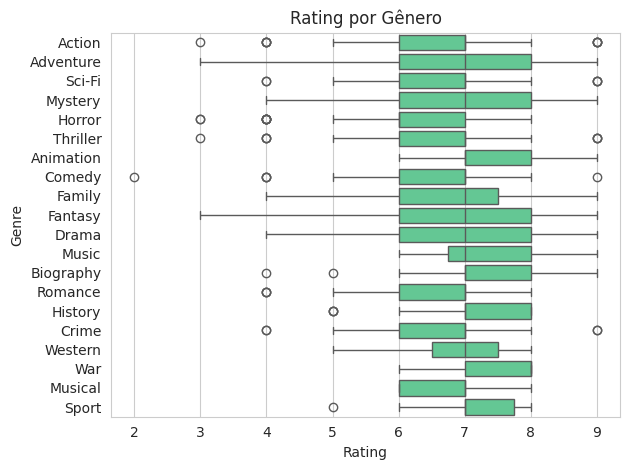

In [ ]:
df_clean = df.dropna(subset=['Rating', 'Genre'])
df_clean['Genre'] = df_clean['Genre'].str.split(',')

df_plot = df_clean.explode('Genre')
df_plot['Genre'] = df_plot['Genre'].str.strip()

sns.boxplot(data=df_plot, x='Rating', y='Genre', color=color_green)
plt.title('Rating por Gênero')
plt.tight_layout()
plt.show()

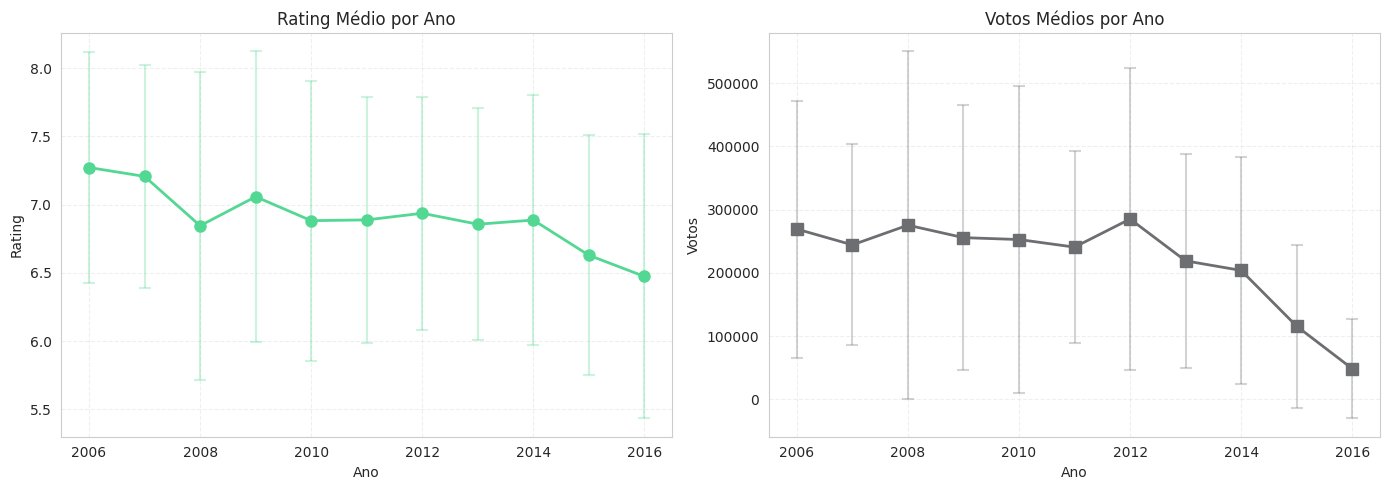

In [ ]:
df_ano = df.groupby('Year').agg({'Rating': ['mean', 'std'],'Votes': ['mean', 'std']}).reset_index()
df_ano.columns = ['Year', 'Rating_mean', 'Rating_std', 'Votes_mean', 'Votes_std']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_ano['Year'], df_ano['Rating_mean'],
         marker='o',
         color=color_green,
         linewidth=2,
         markersize=8)
ax1.errorbar(df_ano['Year'], df_ano['Rating_mean'],
             yerr=df_ano['Rating_std'],
             fmt='none',
             color=color_green,
             capsize=4,
             capthick=1.5,
             alpha=0.3,
             elinewidth=1.5)
ax1.set_title('Rating Médio por Ano')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Rating')
ax1.grid(True, linestyle='--', alpha=0.3)


ax2.plot(df_ano['Year'], df_ano['Votes_mean'],
         marker='s',
         color=color_gray,
         linewidth=2,
         markersize=8)
ax2.errorbar(df_ano['Year'], df_ano['Votes_mean'],
             yerr=df_ano['Votes_std'],
             fmt='none',
             color=color_gray,
             capsize=4,
             capthick=1.5,
             alpha=0.3,
             elinewidth=1.5)
ax2.set_title('Votos Médios por Ano')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Votos')
ax2.grid(True, linestyle='--', alpha=0.3)

sns.set_style('whitegrid')

plt.tight_layout()
plt.show()

####Justificativa

Escolhi o boxplot para comparar a distribuição das notas entre os gêneros, permitindo observar mediana, quartis, dispersão e outliers e achei que seria interessante observar como contaúdos mais ninchados tem uma abrangencia menor de nots. Como os filmes podem pertencer a mais de um gênero, a coluna foi desdobrada para que cada associação fosse analisada separadamente. Os gráficos de linha mostram a evolução anual do rating médio e do número médio de votos evidenciando a queda quase constante nos ultimos anos. As barras de erro representam o desvio-padrão de cada ano e foram incluídas para evidenciar a variabilidade das observações. Mantive as duas métricas em gráficos separados porque possuem escalas e unidades muito diferentes. Essa combinação permite analisar tanto a distribuição das avaliações por gênero quanto as tendências temporais de qualidade percebida e engajamento dos usuários.

#Sobre Uso de IA

Durante a realização desta avaliação, utilizei ferramentas de Inteligência Artificial de forma pontual e complementar, conforme permitido no processo seletivo. O objetivo foi utilizar a IA como apoio técnico, mantendo sob minha responsabilidade a construção das soluções, a implementação dos códigos, a interpretação dos dados e as conclusões apresentadas.

Os principais usos foram:

Esclarecimento de dúvidas técnicas: utilizei IA para consultar conceitos específicos e tirar dúvidas pontuais relacionadas à SQL Injection e a alguns aspectos da abordagem em Python. As respostas foram utilizadas como apoio ao raciocínio e posteriormente avaliadas e aplicadas de acordo com o contexto da avaliação.

Validação de terminologia e abordagem: utilizei a ferramenta para verificar se determinados termos, nomenclaturas e formas de apresentação eram tecnicamente adequados e coerentes com o contexto de uma posição de Analista de Dados Pleno. Esse uso teve caráter principalmente consultivo e de revisão técnica.

Revisão das análises e resultados: após desenvolver as consultas, códigos, gráficos e análises, utilizei IA como uma segunda perspectiva para questionar os resultados obtidos e verificar se havia algum ponto relevante que pudesse ter sido negligenciado. Essa etapa foi utilizada como uma espécie de revisão técnica, buscando identificar possíveis inconsistências, análises complementares ou oportunidades de aprofundamento.

Este documento também foi elaborado com auxílio de Inteligência Artificial. Especificamente, sua geração fez parte do prompt inicial de instrução utilizado para consolidar e documentar os usos de IA realizados ao longo do período de execução da avaliação.